[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imbishal7/CSC-428/blob/main/notebooks/CSC428_project.ipynb)

# CSC428 Final Project — Cross-Dataset Generalization of ML Side-Channel Attacks on AES

Suwan Aryal & Kapil Sharma. Single end-to-end notebook covering all four phases:

1. **Setup + data download** (one-time, idempotent)
2. **Baselines** on synchronized fixed-key ASCAD: logistic regression, MLP, CNN
3. **Cross-variant zero-shot** evaluation on `desync50`, `desync100`, `variable`
4. **Recovery techniques**: data augmentation + transfer learning

Each section saves its results into `results/`, so you can re-run a single section without redoing the previous ones.

> **Repo:** https://github.com/imbishal7/CSC-428

## Section 0 — Colab setup

Mount Drive, clone the repo into Drive (first run only), install dependencies.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive
# First run only — clones the repo into Drive so it persists across sessions:
![ -d CSC-428 ] || git clone https://github.com/imbishal7/CSC-428.git
%cd CSC-428
!pip install -q -r requirements.txt
!nvidia-smi -L

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
Cloning into 'CSC-428'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 0), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 12.35 KiB | 269.00 KiB/s, done.
/content/drive/MyDrive/CSC-428
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-fd557a0f-df1c-27e7-1b99-b8eef7d988bc)


## Section 1 — Download ASCAD

Pulls the fixed-key zip (~4.2 GB) and the variable-key sync file (~418 MB). Skips anything already present. Total disk after extraction ≈ 7.7 GB.

In [4]:
!python scripts/download_data.py
!ls -lh data

[1/2] fixed-key bundle (ASCAD.h5, ASCAD_desync50.h5, ASCAD_desync100.h5)
  downloading -> ASCAD_fixed_key.zip
    100.0%  4.44 / 4.44 GB
  unzipping ASCAD_fixed_key.zip ...
  extracted 3 files
  removed zip
[2/2] variable-key h5 files
  downloading -> ASCAD_variable.h5
    100.0%  0.44 / 0.44 GB

Done. Files under /content/drive/MyDrive/CSC-428/data
  ASCAD.h5                              0.05 GB
  ASCAD_desync100.h5                    0.05 GB
  ASCAD_desync50.h5                     0.05 GB
  ASCAD_variable.h5                     0.44 GB
total 552M
-rw------- 1 root root  45M Apr 28 01:07 ASCAD_desync100.h5
-rw------- 1 root root  45M Apr 28 01:07 ASCAD_desync50.h5
-rw------- 1 root root  45M Apr 28 01:07 ASCAD.h5
-rw------- 1 root root 419M Apr 28 01:09 ASCAD_variable.h5


## Section 2 — Load source variant + fit scaler

In [5]:
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow import keras

from src.data import load_ascad, fit_scaler, apply_scaler, augment_shift, augment_noise
from src.models import build_logreg, build_mlp, build_cnn
from src.train import fit, evaluate_attack, save_result, load_result
from src.transfer import fine_tune, random_subset

Path('results').mkdir(exist_ok=True)

ds_src = load_ascad('data/ASCAD.h5', label_kind='hw')
scaler = fit_scaler(ds_src['X_profiling'])
Xp = apply_scaler(scaler, ds_src['X_profiling'])
Xa = apply_scaler(scaler, ds_src['X_attack'])
Yp, Ya = ds_src['Y_profiling'], ds_src['Y_attack']
pa_src = ds_src['plaintext_attack']
true_key = int(ds_src['key_attack'][0, 2])

with open('scaler_source.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('profiling:', Xp.shape, '  attack:', Xa.shape)
print('class distribution (HW):', np.bincount(Yp, minlength=9))
print('attack key byte (target #2):', true_key)

profiling: (50000, 700)   attack: (10000, 700)
class distribution (HW): [  166  1568  5500 10848 13747 11023  5416  1532   200]
attack key byte (target #2): 224


## Section 3 — Baselines on source variant

Trains logistic regression, MLP, CNN on synchronized fixed-key ASCAD. Saves the MLP and CNN to `.keras` files for re-use in sections 4 and 5.

In [6]:
logreg = build_logreg(input_len=Xp.shape[1], n_classes=9)
fit(logreg, Xp, Yp, epochs=20, batch_size=256)
res_lr = evaluate_attack(logreg, Xa, Ya, pa_src, true_key)
save_result('results', 'baseline_logreg', res_lr, {'variant': 'sync', 'model': 'logreg'})
print(f"LR  top1={res_lr['top1']:.3f}  top5={res_lr['top5']:.3f}  ttr={res_lr['traces_to_recover']}")

Epoch 1/20
176/176 - 7s - 41ms/step - accuracy: 0.1616 - loss: 2.2312 - val_accuracy: 0.1902 - val_loss: 2.1652
Epoch 2/20
176/176 - 0s - 3ms/step - accuracy: 0.2092 - loss: 2.0911 - val_accuracy: 0.2284 - val_loss: 2.0509
Epoch 3/20
176/176 - 0s - 3ms/step - accuracy: 0.2313 - loss: 2.0045 - val_accuracy: 0.2430 - val_loss: 2.0062
Epoch 4/20
176/176 - 0s - 3ms/step - accuracy: 0.2428 - loss: 1.9462 - val_accuracy: 0.2396 - val_loss: 1.9265
Epoch 5/20
176/176 - 0s - 3ms/step - accuracy: 0.2498 - loss: 1.9004 - val_accuracy: 0.2456 - val_loss: 1.9062
Epoch 6/20
176/176 - 0s - 3ms/step - accuracy: 0.2547 - loss: 1.8686 - val_accuracy: 0.2532 - val_loss: 1.8705
Epoch 7/20
176/176 - 1s - 3ms/step - accuracy: 0.2553 - loss: 1.8516 - val_accuracy: 0.2482 - val_loss: 1.8607
Epoch 8/20
176/176 - 0s - 3ms/step - accuracy: 0.2605 - loss: 1.8292 - val_accuracy: 0.2510 - val_loss: 1.8474
Epoch 9/20
176/176 - 0s - 3ms/step - accuracy: 0.2637 - loss: 1.8149 - val_accuracy: 0.2530 - val_loss: 1.8459


In [7]:
mlp = build_mlp(input_len=Xp.shape[1], n_classes=9)
mlp.summary()
fit(mlp, Xp, Yp, epochs=50, batch_size=200)
res_mlp = evaluate_attack(mlp, Xa, Ya, pa_src, true_key)
save_result('results', 'baseline_mlp', res_mlp, {'variant': 'sync', 'model': 'mlp'})
mlp.save('mlp_source.keras')
print(f"MLP top1={res_mlp['top1']:.3f}  top5={res_mlp['top5']:.3f}  ttr={res_mlp['traces_to_recover']}")

Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 700)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       140,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         1,809 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,009 (1.31 MB)

 Trainable params: 343,009 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
225/225 - 12s - 54ms/step - accuracy: 0.2262 - loss: 2.0872 - val_accuracy: 0.2788 - val_loss: 1.9369
Epoch 2/50
225/225 - 1s - 3ms/step - accuracy: 0.2735 - loss: 1.8657 - val_accuracy: 0.2796 - val_loss: 1.8213
Epoch 3/50
225/225 - 1s - 3ms/step - accuracy: 0.2725 - loss: 1.8036 - val_accuracy: 0.2786 - val_loss: 1.7931
Epoch 4/50
225/225 - 1s - 3ms/step - accuracy: 0.2730 - loss: 1.7839 - val_accuracy: 0.2710 - val_loss: 1.7819
Epoch 5/50
225/225 - 1s - 3ms/step - accuracy: 0.2723 - loss: 1.7749 - val_accuracy: 0.2768 - val_loss: 1.7761
Epoch 6/50
225/225 - 1s - 3ms/step - accuracy: 0.2734 - loss: 1.7698 - val_accuracy: 0.2760 - val_loss: 1.7723
Epoch 7/50
225/225 - 1s - 3ms/step - accuracy: 0.2744 - loss: 1.7663 - val_accuracy: 0.2786 - val_loss: 1.7707
Epoch 8/50
225/225 - 1s - 3ms/step - accuracy: 0.2747 - loss: 1.7640 - val_accuracy: 0.2754 - val_loss: 1.7689
Epoch 9/50
225/225 - 1s - 3ms/step - accuracy: 0.2751 - loss: 1.7621 - val_accuracy: 0.2748 - val_loss: 1.7680

In [8]:
Xp_c, Xa_c = Xp[..., None], Xa[..., None]
cnn = build_cnn(input_len=Xp.shape[1], n_classes=9)
cnn.summary()
fit(cnn, Xp_c, Yp, epochs=50, batch_size=200)
res_cnn = evaluate_attack(cnn, Xa_c, Ya, pa_src, true_key)
save_result('results', 'baseline_cnn', res_cnn, {'variant': 'sync', 'model': 'cnn'})
cnn.save('cnn_source.keras')
print(f"CNN top1={res_cnn['top1']:.3f}  top5={res_cnn['top5']:.3f}  ttr={res_cnn['traces_to_recover']}")

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 700, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 700, 64)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 350, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 350, 128)       │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 175, 128)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 175, 256)       │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 87, 256)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 87, 512)        │     1,442,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_3             │ (None, 43, 512)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 43, 512)        │     2,884,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_4             │ (None, 21, 512)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    44,044,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 9)              │        36,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,640,585 (250.40 MB)

 Trainable params: 65,640,585 (250.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
225/225 - 26s - 114ms/step - accuracy: 0.2710 - loss: 1.8334 - val_accuracy: 0.2788 - val_loss: 1.7805
Epoch 2/50
225/225 - 3s - 13ms/step - accuracy: 0.2718 - loss: 1.7760 - val_accuracy: 0.2788 - val_loss: 1.7739
Epoch 3/50
225/225 - 3s - 13ms/step - accuracy: 0.2731 - loss: 1.7726 - val_accuracy: 0.2788 - val_loss: 1.7711
Epoch 4/50
225/225 - 3s - 13ms/step - accuracy: 0.2734 - loss: 1.7693 - val_accuracy: 0.2788 - val_loss: 1.7677
Epoch 5/50
225/225 - 3s - 13ms/step - accuracy: 0.2744 - loss: 1.7666 - val_accuracy: 0.2788 - val_loss: 1.7659
Epoch 6/50
225/225 - 3s - 13ms/step - accuracy: 0.2745 - loss: 1.7646 - val_accuracy: 0.2788 - val_loss: 1.7647
Epoch 7/50
225/225 - 3s - 13ms/step - accuracy: 0.2745 - loss: 1.7629 - val_accuracy: 0.2788 - val_loss: 1.7631
Epoch 8/50
225/225 - 3s - 13ms/step - accuracy: 0.2745 - loss: 1.7618 - val_accuracy: 0.2788 - val_loss: 1.7615
Epoch 9/50
225/225 - 3s - 13ms/step - accuracy: 0.2744 - loss: 1.7613 - val_accuracy: 0.2788 - val_los

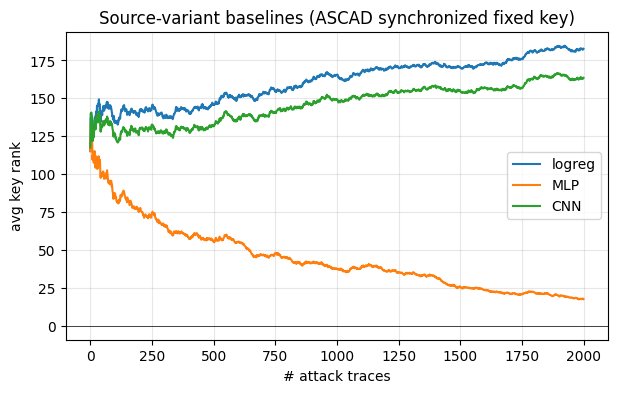

In [9]:
plt.figure(figsize=(7, 4))
for name, res in [('logreg', res_lr), ('MLP', res_mlp), ('CNN', res_cnn)]:
    plt.plot(res['rank_curve'], label=name)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('# attack traces'); plt.ylabel('avg key rank')
plt.title('Source-variant baselines (ASCAD synchronized fixed key)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('results/baseline_rank_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 4 — Cross-variant zero-shot evaluation

Apply the saved MLP and CNN directly (no retraining) to `desync50`, `desync100`, and `variable`. The drop relative to the in-distribution `sync` row is the headline 'how much does performance drop' result.

In [10]:
TARGETS = {
    'sync':      'data/ASCAD.h5',                  # in-distribution reference
    'desync50':  'data/ASCAD_desync50.h5',
    'desync100': 'data/ASCAD_desync100.h5',
    'variable':  'data/ASCAD_variable.h5',
}

rows = []
for tgt, path in TARGETS.items():
    ds_t = load_ascad(path, 'hw')
    Xa_t = apply_scaler(scaler, ds_t['X_attack'])
    pa_t = ds_t['plaintext_attack']
    tk = int(ds_t['key_attack'][0, 2])

    r_mlp = evaluate_attack(mlp, Xa_t,           ds_t['Y_attack'], pa_t, tk)
    r_cnn = evaluate_attack(cnn, Xa_t[..., None], ds_t['Y_attack'], pa_t, tk)
    save_result('results', f'cross_{tgt}_mlp', r_mlp, {'target': tgt, 'model': 'mlp', 'mode': 'zero_shot'})
    save_result('results', f'cross_{tgt}_cnn', r_cnn, {'target': tgt, 'model': 'cnn', 'mode': 'zero_shot'})
    rows.append((tgt, 'mlp', r_mlp['top1'], r_mlp['top5'], r_mlp['traces_to_recover']))
    rows.append((tgt, 'cnn', r_cnn['top1'], r_cnn['top5'], r_cnn['traces_to_recover']))
    print(f"{tgt:9s}  MLP top1={r_mlp['top1']:.3f}  ttr={r_mlp['traces_to_recover']}    CNN top1={r_cnn['top1']:.3f}  ttr={r_cnn['traces_to_recover']}")

df_cross = pd.DataFrame(rows, columns=['target', 'model', 'top1', 'top5', 'traces_to_recover'])
src_ref = df_cross[df_cross.target == 'sync'].set_index('model')[['top1', 'top5']]
df_cross['top1_drop'] = df_cross.apply(lambda r: src_ref.loc[r.model, 'top1'] - r.top1, axis=1)
df_cross['top5_drop'] = df_cross.apply(lambda r: src_ref.loc[r.model, 'top5'] - r.top5, axis=1)
df_cross.to_csv('results/cross_variant_table.csv', index=False)
df_cross

sync       MLP top1=0.269  ttr=None    CNN top1=0.273  ttr=None
desync50   MLP top1=0.225  ttr=None    CNN top1=0.270  ttr=None
desync100  MLP top1=0.219  ttr=None    CNN top1=0.263  ttr=None


ValueError: X has 1400 features, but StandardScaler is expecting 700 features as input.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, mname in zip(axes, ['mlp', 'cnn']):
    for tgt in TARGETS:
        r = load_result('results', f'cross_{tgt}_{mname}')
        ax.plot(r['rank_curve'], label=tgt)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'{mname.upper()} (trained on sync) — zero-shot')
    ax.set_xlabel('# attack traces'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('avg key rank')
plt.savefig('results/cross_variant_rank_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 5 — Recovery technique 1: data augmentation

Retrain MLP and CNN on the *source* variant with random ±50-sample circular shifts applied per epoch. No target traces are seen during training. Then evaluate on every target. Tests whether augmentation alone closes the gap.

In [ ]:
MAX_SHIFT = 50
NOISE_SIGMA = 0.0

class AugSequence(keras.utils.Sequence):
    def __init__(self, X, Y, batch_size=200, max_shift=50, noise_sigma=0.0, channel=False, seed=0):
        self.X, self.Y = X, Y
        self.batch_size = batch_size
        self.max_shift = max_shift
        self.noise_sigma = noise_sigma
        self.channel = channel
        self.rng = np.random.default_rng(seed)
        self.idx = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, i):
        sl = self.idx[i*self.batch_size:(i+1)*self.batch_size]
        xb = self.X[sl]
        if self.max_shift > 0:
            xb = augment_shift(xb, self.max_shift, self.rng)
        if self.noise_sigma > 0:
            xb = augment_noise(xb, self.noise_sigma, self.rng)
        if self.channel:
            xb = xb[..., None]
        return xb, self.Y[sl]

    def on_epoch_end(self):
        self.rng.shuffle(self.idx)

In [ ]:
mlp_aug = build_mlp(input_len=Xp.shape[1], n_classes=9)
mlp_aug.fit(AugSequence(Xp, Yp, batch_size=200, max_shift=MAX_SHIFT, channel=False),
            epochs=50, verbose=2)
mlp_aug.save('mlp_aug.keras')

cnn_aug = build_cnn(input_len=Xp.shape[1], n_classes=9)
cnn_aug.fit(AugSequence(Xp, Yp, batch_size=200, max_shift=MAX_SHIFT, channel=True),
            epochs=50, verbose=2)
cnn_aug.save('cnn_aug.keras')

In [ ]:
rows = []
for tgt, path in TARGETS.items():
    ds_t = load_ascad(path, 'hw')
    Xa_t = apply_scaler(scaler, ds_t['X_attack'])
    pa_t = ds_t['plaintext_attack']
    tk = int(ds_t['key_attack'][0, 2])

    r_mlp = evaluate_attack(mlp_aug, Xa_t,           ds_t['Y_attack'], pa_t, tk)
    r_cnn = evaluate_attack(cnn_aug, Xa_t[..., None], ds_t['Y_attack'], pa_t, tk)
    save_result('results', f'aug_{tgt}_mlp', r_mlp, {'target': tgt, 'model': 'mlp', 'mode': 'augmented'})
    save_result('results', f'aug_{tgt}_cnn', r_cnn, {'target': tgt, 'model': 'cnn', 'mode': 'augmented'})
    rows.append((tgt, 'mlp', r_mlp['top1'], r_mlp['traces_to_recover']))
    rows.append((tgt, 'cnn', r_cnn['top1'], r_cnn['traces_to_recover']))
    print(f"{tgt:9s}  MLP top1={r_mlp['top1']:.3f}  ttr={r_mlp['traces_to_recover']}    CNN top1={r_cnn['top1']:.3f}  ttr={r_cnn['traces_to_recover']}")

df_aug = pd.DataFrame(rows, columns=['target', 'model', 'top1', 'traces_to_recover'])
df_aug.to_csv('results/augmentation_table.csv', index=False)
df_aug

In [ ]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(4 * len(TARGETS), 4), sharey=True)
for ax, tgt in zip(axes, TARGETS):
    for label, prefix in [('zero-shot', 'cross'), ('augmented', 'aug')]:
        r = load_result('results', f'{prefix}_{tgt}_cnn')
        ax.plot(r['rank_curve'], label=f'CNN {label}')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(tgt); ax.set_xlabel('# attack traces')
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('avg key rank')
plt.suptitle('Augmentation effect on CNN cross-variant transfer', y=1.02)
plt.savefig('results/augmentation_rank_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 6 — Recovery technique 2: transfer learning

Reload the source-trained MLP / CNN, freeze all but the last dense layer, and fine-tune on a small slice of the target's profiling traces. Sweep budget ∈ {500, 1000, 2000, 5000}. Each fine-tune starts from the same source weights so budgets are directly comparable.

In [ ]:
SOURCE_MODELS = {'mlp': 'mlp_source.keras', 'cnn': 'cnn_source.keras'}
TRANSFER_TARGETS = {
    'desync50': 'data/ASCAD_desync50.h5',
    'variable': 'data/ASCAD_variable.h5',
}
BUDGETS = [500, 1000, 2000, 5000]

rows = []
for tgt, path in TRANSFER_TARGETS.items():
    ds_t = load_ascad(path, 'hw')
    Xp_t = apply_scaler(scaler, ds_t['X_profiling'])
    Yp_t = ds_t['Y_profiling']
    Xa_t = apply_scaler(scaler, ds_t['X_attack'])
    Ya_t = ds_t['Y_attack']
    pa_t = ds_t['plaintext_attack']
    tk = int(ds_t['key_attack'][0, 2])

    for mname, src_path in SOURCE_MODELS.items():
        is_cnn = mname == 'cnn'
        base = load_result('results', f'cross_{tgt}_{mname}')
        rows.append((tgt, mname, 0, base['top1'], base['traces_to_recover']))
        print(f"{tgt:9s}  {mname}  N=    0  top1={base['top1']:.3f}  ttr={base['traces_to_recover']}")

        for n in BUDGETS:
            mdl = keras.models.load_model(src_path)
            xs, ys = random_subset(Xp_t, Yp_t, n=n, seed=42)
            if is_cnn:
                xs = xs[..., None]
            fine_tune(mdl, xs, ys, freeze_until=len(mdl.layers) - 1,
                      lr=1e-4, epochs=20, batch_size=min(64, max(8, n // 8)), verbose=0)
            xa = Xa_t[..., None] if is_cnn else Xa_t
            res = evaluate_attack(mdl, xa, Ya_t, pa_t, tk)
            save_result('results', f'transfer_{tgt}_{mname}_n{n}', res,
                        {'target': tgt, 'model': mname, 'budget': n, 'mode': 'transfer'})
            rows.append((tgt, mname, n, res['top1'], res['traces_to_recover']))
            print(f"{tgt:9s}  {mname}  N={n:5d}  top1={res['top1']:.3f}  ttr={res['traces_to_recover']}")

df_t = pd.DataFrame(rows, columns=['target', 'model', 'budget', 'top1', 'traces_to_recover'])
df_t.to_csv('results/transfer_table.csv', index=False)
df_t

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, ylabel, log in zip(axes, ['top1', 'traces_to_recover'],
                                   ['top-1 acc', 'traces to recover (lower is better)'],
                                   [False, True]):
    for (tgt, mname), grp in df_t.groupby(['target', 'model']):
        grp = grp.sort_values('budget')
        ax.plot(grp.budget, grp[metric], marker='o', label=f'{tgt}/{mname}')
    ax.set_xlabel('# target profiling traces used for fine-tuning')
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3); ax.legend()
    if log:
        ax.set_yscale('log')
plt.suptitle('Transfer learning: recovery vs. target-trace budget', y=1.02)
plt.savefig('results/transfer_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 7 — Final summary table for the report

In [ ]:
summary = []
for jf in sorted(Path('results').glob('*.json')):
    summary.append(json.loads(jf.read_text()))
summary_df = pd.DataFrame(summary)
summary_df.to_csv('results/all_results.csv', index=False)
summary_df